# 03 · Does the confidence mean anything?

Accuracy says how often the model is right. It says nothing about whether the number printed
beside a prediction can be trusted — and for a nutrition app, a confidently wrong answer is
worse than an uncertain one.

Two things are established here: a calibrated confidence, and a coverage guarantee that
holds without assuming anything about the model.

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORTS = ROOT / "artifacts" / "reports"

# Chart palette, validated for the lightness band, chroma floor, colour-vision
# separation and contrast. The interface accents fail as data marks: they sit
# too light and drop under 3:1 against the page. Order matters — green beside
# amber fails deuteranope separation, so teal sits between them.
INK, DIM = "#0b0b0f", "#4b4b55"
C = ["#e62429", "#1b4ce0", "#c07708", "#0e8fa3", "#16a34a"]

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": DIM, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": DIM, "ytick.color": DIM,
    "axes.grid": True, "grid.color": "#e6e4dc", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "legend.frameon": False,
})

In [2]:
cal = json.loads((REPORTS / "calibration_ensemble_siglip_eva02.json").read_text())
before, after = cal["test_before"], cal["test_after"]

print(f"fitted temperature   {cal['temperature']}")
print(f"  < 1 sharpens an under-confident model; > 1 softens an over-confident one\n")
for k in ["top1", "ece", "mce", "brier", "nll", "mean_confidence"]:
    print(f"  {k:<16} {before[k]:>9.5f}  →  {after[k]:>9.5f}")

fitted temperature   0.7621
  < 1 sharpens an under-confident model; > 1 softens an over-confident one

  top1              97.15600  →   97.15600
  ece                0.05135  →    0.00624
  mce                0.25739  →    0.18958
  brier              0.05136  →    0.04605
  nll                0.15579  →    0.11871
  mean_confidence    0.92021  →    0.96590


**The ensemble was under-confident**, which is the less common direction. Temperature below
1 sharpens it. Expected calibration error falls eightfold, and mean confidence moves from
92.0% to 96.6% against 97.16% accuracy — those now agree.

Accuracy is unchanged, and must be: temperature scaling is monotonic, so it cannot reorder
predictions. It changes only what the number means.

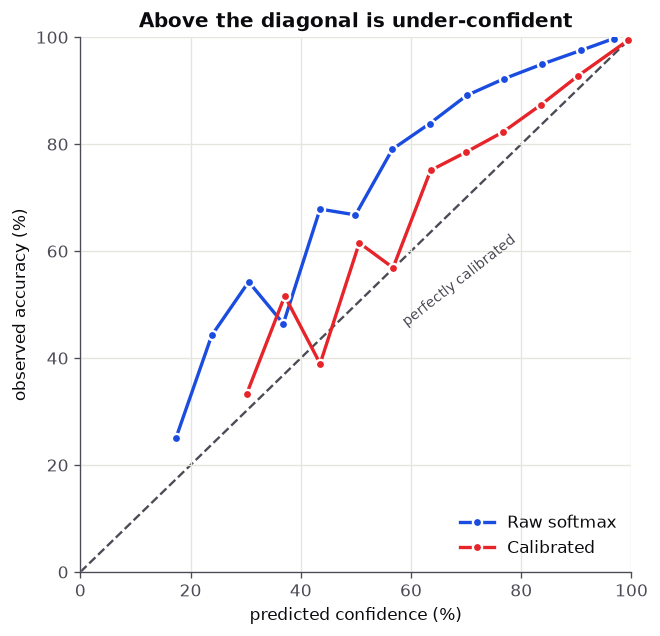

In [3]:
MIN_COUNT = 25   # bins with a handful of images swing wildly and are not evidence

fig, ax = plt.subplots(figsize=(5.6, 5.4))
ax.plot([0, 100], [0, 100], "--", color=DIM, lw=1.4, zorder=1)
ax.text(58, 46, "perfectly calibrated", rotation=38, color=DIM, fontsize=8.5)

for bins, label, colour in [(before["bins"], "Raw softmax", C[1]),
                            (after["bins"], "Calibrated", C[0])]:
    b = [x for x in bins if x["count"] >= MIN_COUNT]
    ax.plot([x["confidence"]*100 for x in b], [x["accuracy"]*100 for x in b],
            "-o", color=colour, lw=2, ms=5.5, mec="white", mew=1.4, label=label, zorder=3)

ax.set_xlabel("predicted confidence (%)"); ax.set_ylabel("observed accuracy (%)")
ax.set_title("Above the diagonal is under-confident")
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## Conformal prediction sets

A calibrated confidence is still a claim about one image. A conformal set is a claim about
the *procedure*: over repeated use the true class lands inside the set at least (1 − α) of
the time, with no assumption about the model — only that calibration and test data are
exchangeable.

In [4]:
conf = json.loads((REPORTS / "conformal.json").read_text())
rows = []
for r in conf["results"]:
    for method in ["lac", "aps", "lac_top1", "aps_top1"]:
        m = r.get(method)
        if m:
            rows.append({"target": r["target_coverage"], "method": method.upper(),
                         "coverage": m["coverage"], "mean size": m["avg_set_size"],
                         "singletons %": m["singleton_rate"], "empty %": m["empty_rate"],
                         "max": m["max_set_size"]})
pd.DataFrame(rows)

,target,method,coverage,mean size,singletons %,empty %,max
0,90.0,LAC,93.588,0.946,94.606,5.394,1
1,90.0,APS,90.182,1.542,80.404,8.954,48
2,90.0,LAC_TOP1,97.156,1.000,100.000,0.000,1
3,90.0,APS_TOP1,97.156,1.000,100.000,0.000,1
4,95.0,LAC,96.871,0.995,98.218,1.141,2
5,95.0,APS,95.556,2.517,79.747,3.905,60
6,95.0,LAC_TOP1,97.156,1.000,100.000,0.000,1
7,95.0,APS_TOP1,97.156,1.000,100.000,0.000,1
8,99.0,LAC,99.560,1.544,75.929,0.000,23
9,99.0,APS,99.382,7.120,54.586,0.440,77


Two findings that changed the product.

**95% coverage is not a meaningful target for this model.** Top-1 accuracy is 97.16%, so any
target below that is already satisfied by the single best guess — the threshold collapses to
zero and the "prediction set" contains one class. The machinery only does work at 99%, where
LAC with a forced top-1 covers 99.56% at an average of 1.54 candidates and never returns
empty. That is the shipping configuration.

**Calibration and deployment must apply the identical rule.** An earlier version forced the
top-1 class into the set at test time but scored *without* it during calibration. That
silently rescued the ~13% of images whose top score exceeded the threshold, and produced
99.1% empirical coverage against a 90% target. The guarantee was void — and the number
looked *better* for it, which is what makes this class of bug dangerous.

## Abstention

Neither signal is sufficient alone.

In [5]:
from scipy.special import softmax

LOGITS = REPORTS / "logits"
T, THR = cal["temperature"], 0.4189
p = np.mean([softmax(np.load(LOGITS / f"probe_{n}_test.npy").astype(np.float64) / T, axis=1)
             for n in ["siglip_so400m", "eva02_large"]], axis=0)
y = np.load(LOGITS / "test_y.npy")

qhat = [r for r in conf["results"] if r["alpha"] == 0.01][0]["lac_top1"]["qhat"]
sets = p >= (1 - qhat)
sets[np.arange(len(p)), p.argmax(1)] = True
sizes, correct = sets.sum(1), p.argmax(1) == y

for label, flag in [("max-prob only", p.max(1) < THR),
                    ("set size >= 5 only", sizes >= 5),
                    ("either (shipped)", (p.max(1) < THR) | (sizes >= 5))]:
    print(f"{label:<22} abstains on {flag.mean()*100:5.2f}%   "
          f"accuracy on the rest {correct[~flag].mean()*100:.2f}%")
print(f"\nno abstention          {'':<12}   accuracy {correct.mean()*100:.2f}%")

max-prob only          abstains on  0.72%   accuracy on the rest 97.55%
set size >= 5 only     abstains on  2.19%   accuracy on the rest 97.89%
either (shipped)       abstains on  2.28%   accuracy on the rest 97.94%

no abstention                         accuracy 97.16%


Max-probability alone catches random noise but let a flat colour field through at 0.43,
classified "breakfast burrito". Conformal set size caught that at eight candidates, where
every correctly classified dish returned one. Combining them lifts served accuracy from
97.16% to 97.94% at the cost of declining 2.28% of real food.

This is an *abstention* rule, not a trained out-of-distribution detector. It reports that
the model is lost, which correlates with but is not the same as "this is not food".